In [4]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from src.preprocessing import build_dataset, IMG_SIZE, BATCH_SIZE, SEED

In [9]:
TRAIN_DIR = "../dataset/train"
TEST_DIR = "../dataset/test"

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Train directory: ../dataset/train
Test directory: ../dataset/test


In [10]:
class_names = sorted([
    name for name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, name))
])

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Classes:", class_names)
print("Class mapping:", class_to_index)

Classes: ['10_rupee', '1_rupee', '2_rupee', '5_rupee']
Class mapping: {'10_rupee': 0, '1_rupee': 1, '2_rupee': 2, '5_rupee': 3}


In [11]:
# function to collect images
def get_image_paths_and_labels(directory):
    image_paths = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                image_paths.append(
                    os.path.join(class_dir, file_name)
                )
                labels.append(class_to_index[class_name])

    return image_paths, labels

In [12]:
train_paths, train_labels = get_image_paths_and_labels(TRAIN_DIR)
test_paths, test_labels= get_image_paths_and_labels(TEST_DIR)

print("Training Images:", len(train_paths))
print("test images: ", len(test_paths))

Training Images: 510
test images:  150


In [15]:
VALIDATION_DIR = "../dataset/validation"

print("Validation directory:", VALIDATION_DIR)

Validation directory: ../dataset/validation


In [16]:
val_paths, val_labels = get_image_paths_and_labels(VALIDATION_DIR)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 510
Validation images: 120
Test images: 150


In [17]:
train_dataset = build_dataset(
    train_paths,
    train_labels,
    is_training=True
)

val_dataset = build_dataset(
    val_paths,
    val_labels,
    is_training=False
)

test_dataset = build_dataset(
    test_paths,
    test_labels,
    is_training=False
)

print("Train dataset created.")
print("Validation dataset created.")
print("Test dataset created.")

Train dataset created.
Validation dataset created.
Test dataset created.


In [18]:
for images, labels in train_dataset.take(1):

    print("Train batch shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Data type:", images.dtype)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Train batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Data type: <dtype: 'float32'>
Minimum pixel value: 0.0032419646
Maximum pixel value: 0.99999994


In [19]:
# Build the CNN Model
model = tf.keras.Sequential([

    # Input image: 128 x 128 RGB
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Feature extraction
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Downsampling
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # More feature extraction
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Downsampling
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps into a vector
    tf.keras.layers.Flatten(),

    # Classification
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Prevent overfitting
    tf.keras.layers.Dropout(0.5),

    # 4 coin classes
    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])

In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [22]:
print("Model compiled successfully.")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy")
print("Metric: Accuracy")

Model compiled successfully.
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Metric: Accuracy


In [23]:
# Train the CNN
EPOCHS = 25

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/25


c:\mudravision-ai\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 469ms/step - accuracy: 0.3118 - loss: 1.7309 - val_accuracy: 0.2583 - val_loss: 1.3815
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 447ms/step - accuracy: 0.3961 - loss: 1.2964 - val_accuracy: 0.3417 - val_loss: 1.2521
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 343ms/step - accuracy: 0.4824 - loss: 1.1927 - val_accuracy: 0.3583 - val_loss: 1.1337
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 437ms/step - accuracy: 0.6000 - loss: 1.0195 - val_accuracy: 0.4333 - val_loss: 1.1017
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 491ms/step - accuracy: 0.6392 - loss: 0.8956 - val_accuracy: 0.4333 - val_loss: 1.4239
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 383ms/step - accuracy: 0.6627 - loss: 0.8307 - val_accuracy: 0.4583 - val_loss: 1.2809
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 381ms/step - accuracy: 0.7000 - loss: 0.7583 - val_accuracy: 0.4583 - val_loss: 1.1986
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 422ms/step - accuracy: 0.6706 - loss: 0.7892 - val_accuracy: 0.616

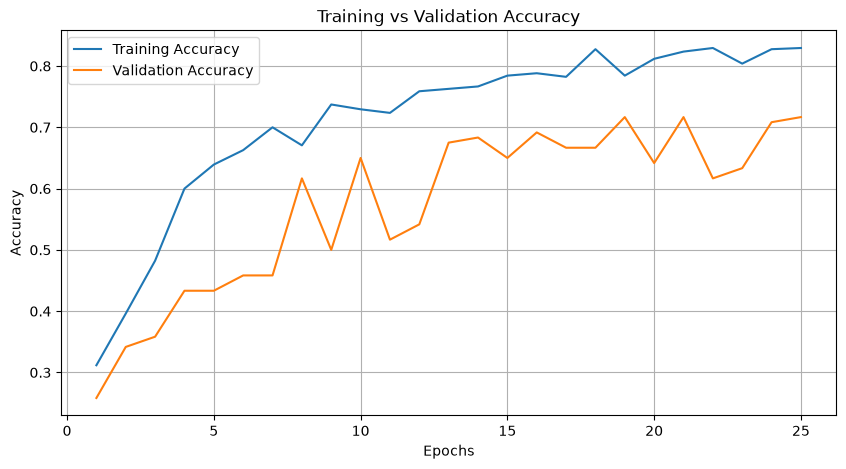

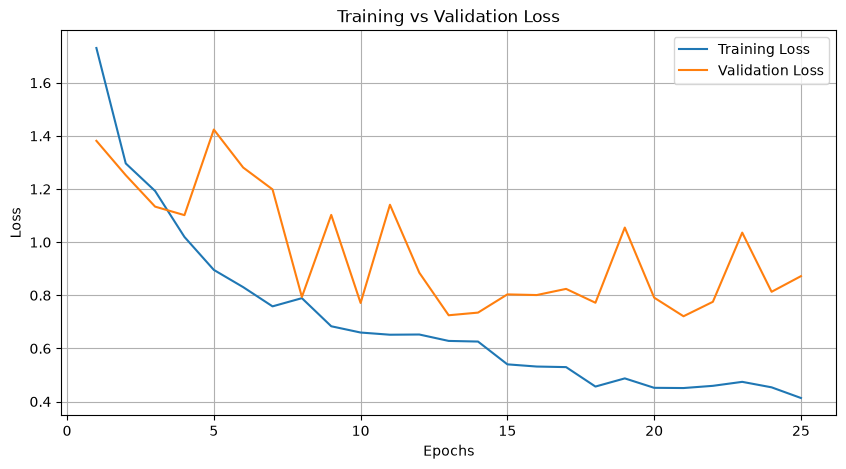

In [24]:
import matplotlib.pyplot as plt

# Get training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)


# ============================================================
# Accuracy Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Loss Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# STEP 1.4 — SAVE THE TRAINED MODEL
# ============================================================

import os

MODEL_PATH = "../models/coin_classifier.keras"

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model.save(MODEL_PATH)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: ../models/coin_classifier.keras
